# 29 — Canonical Full-Scale Smoke (offline messages + local LLM, package mode)

This is the **new canonical full-run reference notebook** for Climate-Action-GABM. It supersedes NB19 as the go-to template for full-flow runs going forward. NB19 is preserved unchanged as the historical OpenAI/gpt-5-mini baseline.

**What this notebook proves end-to-end**

1. The full simulation pipeline runs cleanly with **offline political messages** (set `v1`) as the broadcast source — zero LLM calls for political broadcasts.
2. The full pipeline runs cleanly on a **local LLM** (Qwen3-8B via `mlx_lm.server`) for everything else (surveys, reflections, peer messages).
3. **Package mode** end-to-end (`communication_mode='package'`, alternating `[P-A,P-B,C]`/`[P-B,P-A,C]` phase order across days) over multiple policies and multiple days.
4. **Day-0 anchoring from ground truth** (`day0_anchor='ground_truth_with_rationale'`): numeric Day-0 opinion equals YouGov ground truth exactly; the LLM only writes the rationale.
5. Every `political_broadcast` row in the saved messages log carries a non-empty `political_message_id` that round-trips back to `messages_v1.csv`.
6. `save_results` + `save_result_plots` produce the full canonical artifact set in a fresh timestamped output directory.

**Profile (intentionally small for fast iteration; scale up freely)**

- 15 citizens, 3 days, 3 policies (Carbon Tax / Renewable Energy / Ban Petrol Cars)
- Package mode with alternating phase order (P-A first on odd days, P-B first on even)
- Local Qwen3-8B-4bit on `http://localhost:8080/v1` (see [Local_LLM_Setup_Guide.md](../docs/Local_LLM_Setup_Guide.md))
- Default exposure (`rule_affinity_rank`, balanced weights, symmetric committed-minority targets)
- Symmetric reach (`reach_a=reach_b=1.0`), no audience cap, `k_peers_per_day=3`
- `thinking=False`, `debias=False`, `random_seed=42`

**Project convention.** Offline political messages + local Qwen3 is the research default. API providers (OpenAI / Anthropic / Google) remain available as an outsider option for users without a local LLM setup, but are not the canonical research path.

**Prereq.** `mlx_lm.server` must already be running on `http://localhost:8080/v1` with `mlx-community/Qwen3-8B-4bit` loaded. See NB25 and the local LLM setup guide for the one-command launcher.

## 1. Imports, logging, and local-server ping

Fail-fast if the local server is unreachable, before we build any agents.

In [1]:
import os, sys, random, logging, time
from pathlib import Path

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s', force=True)
logging.getLogger('httpx').setLevel(logging.WARNING)
logging.getLogger('openai').setLevel(logging.WARNING)
logging.getLogger('httpcore').setLevel(logging.WARNING)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cag.io.llm import ping_local, configure_local
from cag.io.survey import load
from cag.abm.political_messages import load_message_pool, PACKAGE_KEY
from cag.abm.attributes.opinion import ALL_CLIMATE_POLICIES, ClimatePolicyID

LOCAL_BASE_URL = 'http://localhost:8080/v1'
LOCAL_MODEL    = 'mlx-community/Qwen3-8B-4bit'

info = ping_local(base_url=LOCAL_BASE_URL)
print('Local server reachable. /v1/models returned:', info)

Local server reachable. /v1/models returned: {'object': 'list', 'data': [{'id': 'mlx-community/Qwen3-8B-4bit', 'object': 'model', 'created': 1779473544}]}


## 2. Standalone pool sanity check

Load `messages_v1.csv` directly and confirm every `(side, policy)` cell — single-policy and PACKAGE — is non-empty before we hand it to the simulator. This is the same standalone check as NB28 §1; it should never fail in a clean checkout.

In [2]:
pool = load_message_pool('v1', seed=42)

rows = []
for side in ('A', 'B'):
    for pid in ALL_CLIMATE_POLICIES:
        rows.append({'side': side, 'policy_id': str(pid), 'cell_size': pool.cell_size(side, pid)})
    rows.append({'side': side, 'policy_id': PACKAGE_KEY, 'cell_size': pool.cell_size(side, PACKAGE_KEY)})

cell_df = pd.DataFrame(rows)
print(f'Total cells: {len(cell_df)} (12 single-policy + 2 package)')
print(f'Empty cells: {(cell_df.cell_size == 0).sum()} (must be 0)')
cell_df

2026-05-22 19:12:27,300 [INFO] Loaded offline message pool 'v1': 14 cells, 280 messages, 24 sources (seed=42)


Total cells: 14 (12 single-policy + 2 package)
Empty cells: 0 (must be 0)


,side,policy_id,cell_size
0,A,ClimatePolicyID(1),20
1,A,ClimatePolicyID(2),20
2,A,ClimatePolicyID(3),20
3,A,ClimatePolicyID(4),20
4,A,ClimatePolicyID(5),20
5,A,ClimatePolicyID(6),20
6,A,PACKAGE,20
7,B,ClimatePolicyID(1),20
8,B,ClimatePolicyID(2),20
9,B,ClimatePolicyID(3),20


## 3. Build a 15-agent SurveyedNation

Same construction pattern as NB17/NB19/NB28, scaled to 15 agents. The two `PoliticalAgent`s are created by `run_simulation` itself — we do not attach them here.

In [4]:
from cag.abm.agent import SurveyedCitizen, PoliticalAgent
from cag.abm.environment import SurveyedNation

from gabm.abm.attributes.gender import GenderMap, GenderID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.democracy.election import ElectionID
from cag.abm.attributes.region import UKRegionMap, RegionID
from cag.abm.attributes.education import SurveyEducationMap, EducationID
from cag.abm.attributes.ethnicity import SurveyEthnicityMap, EthnicityID
from cag.abm.attributes.income import SurveyIncomeMap, IncomeID
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.family import SurveyFamilyMap, FamilyID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteMap, UKGE2019VoteID
from cag.abm.democracy.elections.brexit import BrexitVoteMap, BrexitVoteID
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7,
)

N_CITIZENS  = 10
RANDOM_SEED = 42
year = 2026
random.seed(RANDOM_SEED)

UKGE2019_ELECTION_ID  = ElectionID(0)
BREXIT_REFERENDUM_ID  = ElectionID(1)

sn = SurveyedNation(
    year=year, place='UK',
    gender_map=GenderMap(),
    region_map=UKRegionMap(),
    education_map=SurveyEducationMap(),
    ethnicity_map=SurveyEthnicityMap(),
    income_map=SurveyIncomeMap(),
    politics_map=SurveyPoliticsMap(),
    family_map=SurveyFamilyMap(),
    ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
    brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
    selftransc_map=SelftranscMap,
    selfenh_map=SelfenhMap,
    openness_map=OpennessMap,
    conformtrad_map=ConformTradMap,
    sdo_map=SDOMap,
    edo_map=EDOMap,
    rwa_map=RWAMap,
)

data = load('../data/yougov_survey_data/YouGovProcessedData.csv')
data = data.sample(n=N_CITIZENS, random_state=RANDOM_SEED).reset_index(drop=True)

for i in range(len(data)):
    row = data.iloc[i]
    sc = SurveyedCitizen(
        agent_id=row.get('ID', None), environment=sn,
        year_of_birth=year - int(row.get('age', 0)),
        gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
        region_id=RegionID(int(row.get('tprofile_GOR', 0))),
        education_id=EducationID(int(row.get('profile_education_level', 0))),
        income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
        ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
        family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
        ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
        brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
        politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
        selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
        selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
        openness_id=rescale_1_6(int(row.get('Openness', 0))),
        conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
        sdo_id=rescale_1_7(int(row.get('SDO', 0))),
        edo_id=rescale_1_7(int(row.get('EDO', 0))),
        rwa_id=rescale_1_6(int(row.get('RWA', 0))),
        original_survey_data=data.iloc[i],
    )
    sn.agents_active[sc.id] = sc

print(f'Citizens loaded: {len(sn.agents_active)} (target {N_CITIZENS})')

2026-05-22 19:13:50,217 [INFO] Columns with NaN counts (before filtering):
tprofile_gross_household    398
Political_Left_Right          6
dtype: int64
2026-05-22 19:13:50,217 [INFO] Column with most NaNs: tprofile_gross_household (398 NaNs)
2026-05-22 19:13:50,220 [INFO] 1483 rows after filtering.


Citizens loaded: 10 (target 10)


## 4. Canonical SIM_CONFIG (full, every key visible)

This block lists **every** key in `cag.abm.sim.SIM_CONFIG`. The intent is for you to read this cell and see the full configuration of a research run without jumping into the source. Comments mark each line:

- `# default` — value equals the source default in `cag.abm.sim.SIM_CONFIG`.
- `# SMOKE OVERRIDE (full=X)` — value differs from the full-run target purely because this is a smoke test; the comment shows the full-run value.

The only smoke knobs are `n_citizens`, `days`, and `k_peers_per_day`. Everything else matches the research-canon defaults (local Qwen3, package mode, debias on, day-0 ground-truth-with-rationale, offline message pool). Override here only when you know why.

In [ ]:
from cag.abm.sim import SIM_CONFIG

config = {
    # ---- Population --------------------------------------------------------
    'n_citizens'                 : N_CITIZENS,                          # SMOKE OVERRIDE (full=100)

    # ---- Day plan ----------------------------------------------------------
    # Smoke: 3 alternating package-mode days. Source default is 2 days.
    # No per-day `policy` key (package mode broadcasts ALL package_policies each phase).
    'days': [                                                           # SMOKE OVERRIDE (full=2 days)
        {'phases': ['P-A', 'P-B', 'C']},
        {'phases': ['P-B', 'P-A', 'C']}
    ],

    # ---- Peer messaging ----------------------------------------------------
    'k_peers_per_day'            : 2,                                   # SMOKE OVERRIDE (full=3)

    # ---- Network -----------------------------------------------------------
    'network_type'               : 'stochastic_block',                  # default
    'network_params'             : None,                                # default (legacy flat keys below)
    'p_intra'                    : 0.15,                                # default
    'p_inter'                    : 0.02,                                # default
    'block_sizes'                : None,                                # default (auto from politics_id)
    'diagnostics_timeout_s'      : 30.0,                                # default

    # ---- LLM (research canon: local Qwen3 via mlx_lm.server) --------------
    'llm_model'                  : LOCAL_MODEL,                         # default = 'mlx-community/Qwen3-8B-4bit'
    'llm_provider'               : 'local',                             # default
    'llm_temperature'            : 0.5,                                 # default
    'survey_model'               : None,                                # default (use llm_model for surveys too)
    'survey_provider'            : None,                                # default
    'thinking'                   : True,                               # default (flip True for harder prompts)
    'debias'                     : True,                                # default (Condition B 2-step survey, research canon since v0.3 / NB15)

    # ---- Communication mode + package policies ----------------------------
    'communication_mode'         : 'package',                           # default (all package_policies broadcast together)
    'package_policies'           : list(ALL_CLIMATE_POLICIES),          # default (ALL six policies; do not subset)

    # ---- Political messaging (offline pool is research default) -----------
    'political_message_source'   : 'offline',                           # default ('llm' uses PoliticalAgent.generate_* live)
    'political_message_set'      : 'v1',                                # default (data/political_messages/messages_v1.csv)

    # ---- Day-0 anchoring (research canon) ---------------------------------
    'day0_anchor'                : 'ground_truth_with_rationale',       # default (seed numeric Day-0 from YouGov; LLM writes rationale only)

    # ---- Political-agent reach + audience ---------------------------------
    'reach_a'                    : 1.0,                                 # default (full audience for pro-climate broadcasts)
    'reach_b'                    : 1.0,                                 # default (full audience for anti-climate broadcasts)
    'audience_cap'               : None,                                # default (no cap)

    # ---- Political exposure assignment ------------------------------------
    'political_exposure_mode'    : 'rule_affinity_rank',                # default
    'political_exposure_targets' : None,                                # default (committed_minority_symmetric preset)
    'affinity_weights'           : None,                                # default (balanced preset)

    # ---- Reproducibility + IO ---------------------------------------------
    'random_seed'                : RANDOM_SEED,                         # default (42)
    'output_dir'                 : 'data/output/experiments',           # default

    # ---- Local-LLM runtime knobs (provider='local') -----------------------
    'local_base_url'             : LOCAL_BASE_URL,                      # default = None → env CAG_LOCAL_BASE_URL or http://localhost:8080/v1
    'local_extra_body'           : None,                                # default
    'local_timeout_s'            : None,                                # default = None → env CAG_LOCAL_TIMEOUT_S or 600s
}

# Sanity check: every SIM_CONFIG key is listed here.
missing = sorted(set(SIM_CONFIG) - set(config))
extra   = sorted(set(config)     - set(SIM_CONFIG))
assert not missing, f'NB29 config is missing keys present in SIM_CONFIG: {missing}'
assert not extra,   f'NB29 config has keys not in SIM_CONFIG: {extra}'
print(f'Config has all {len(config)} SIM_CONFIG keys explicit.')

print()
print(f'n_citizens         = {config["n_citizens"]}  (SMOKE; full=100)')
print(f'days               = {len(config["days"])} (SMOKE; full=2), phases alternating P-A/P-B first')
print(f'k_peers_per_day    = {config["k_peers_per_day"]}  (SMOKE; full=3)')
print(f'communication_mode = {config["communication_mode"]}')
print(f'package_policies   = ALL {len(config["package_policies"])} climate policies')
print(f'political_message  = {config["political_message_source"]} (set {config["political_message_set"]})')
print(f'LLM                = {config["llm_provider"]}/{config["llm_model"]} @ {config["local_base_url"]}')
print(f'debias             = {config["debias"]}')
print(f'day0_anchor        = {config["day0_anchor"]}')
print(f'seed               = {config["random_seed"]}')

Config has all 32 SIM_CONFIG keys explicit.

n_citizens         = 10  (SMOKE; full=200)
days               = 2 (SMOKE; full=2), phases alternating P-A/P-B first
k_peers_per_day    = 2  (SMOKE; full=3)
communication_mode = package
package_policies   = ALL 6 climate policies
political_message  = offline (set v1)
LLM                = local/mlx-community/Qwen3-8B-4bit @ http://localhost:8080/v1
debias             = True
day0_anchor        = ground_truth_with_rationale
seed               = 42


## 5. Run the simulation (with broadcast LLM-call tripwire)

We wrap both `PoliticalAgent.generate_message` (single-policy broadcasts) and `PoliticalAgent.generate_package_message` (package broadcasts) so we can prove the LLM is **never** invoked for the political broadcast text in offline mode. The expected count is 0; any non-zero value indicates a regression in the offline branch.

In [6]:
from cag.abm.sim import run_simulation

_orig_single  = PoliticalAgent.generate_message
_orig_package = PoliticalAgent.generate_package_message
_calls = {'single': 0, 'package': 0}

def _trip_single(self, *args, **kwargs):
    _calls['single'] += 1
    return _orig_single(self, *args, **kwargs)

def _trip_package(self, *args, **kwargs):
    _calls['package'] += 1
    return _orig_package(self, *args, **kwargs)

PoliticalAgent.generate_message         = _trip_single
PoliticalAgent.generate_package_message = _trip_package

t0 = time.perf_counter()
try:
    results = run_simulation(config, sn)
finally:
    PoliticalAgent.generate_message         = _orig_single
    PoliticalAgent.generate_package_message = _orig_package
wall = time.perf_counter() - t0

print(f'\nSimulation complete in {wall/60:.1f} min ({wall:.0f}s)')
print(f'PoliticalAgent.generate_message         calls: {_calls["single"]}  (must be 0)')
print(f'PoliticalAgent.generate_package_message calls: {_calls["package"]} (must be 0)')

assert _calls['single']  == 0, 'offline mode invoked single-policy LLM broadcast — regression!'
assert _calls['package'] == 0, 'offline mode invoked package LLM broadcast — regression!'

2026-05-22 19:20:17,827 [INFO] Loaded offline message pool 'v1': 14 cells, 280 messages, 24 sources (seed=42)
2026-05-22 19:20:17,828 [INFO] Reach subsample: agent_a audience 4/4 (reach_a=1.0)
2026-05-22 19:20:17,829 [INFO] Reach subsample: agent_b audience 4/4 (reach_b=1.0)
2026-05-22 19:20:17,835 [INFO] Simulation: 10 agents, 2 days
2026-05-22 19:20:17,835 [INFO] Running package baseline survey (day 0), policies=['ClimatePolicyID(1)', 'ClimatePolicyID(2)', 'ClimatePolicyID(3)', 'ClimatePolicyID(4)', 'ClimatePolicyID(5)', 'ClimatePolicyID(6)'], anchor=ground_truth_with_rationale
2026-05-22 19:20:17,835 [INFO] day0_anchor=ground_truth_with_rationale: debias flag is ignored on Day 0 (still applies to end-of-day surveys).
2026-05-22 20:04:27,214 [INFO] Day 0 mean package index: +0.75
2026-05-22 20:04:27,223 [INFO] --- Day 1/2 (package=climate_policy_package, phases=['P-A', 'P-B', 'C']) ---
2026-05-22 20:07:26,964 [INFO] [P-A] Day 1: delivered package message to 4 citizens. Message (first


Simulation complete in 251.1 min (15067s)
PoliticalAgent.generate_message         calls: 0  (must be 0)
PoliticalAgent.generate_package_message calls: 0 (must be 0)


## 6. Save artifacts

`save_results` writes the canonical CSV/JSON bundle to a fresh timestamped subdirectory under `data/output/experiments/`; `save_result_plots` writes the standard plot set into the same directory and returns a `{name: path}` mapping.

2026-05-22 23:49:59,086 [INFO] Results saved to ../data/output/experiments/20260522_234958
2026-05-22 23:49:59,894 [INFO] Plot saved to ../data/output/experiments/20260522_234958/opinion_trajectories.png
2026-05-22 23:50:00,298 [INFO] Plot saved to ../data/output/experiments/20260522_234958/opinion_shares.png
2026-05-22 23:50:00,389 [INFO] Plot saved to ../data/output/experiments/20260522_234958/package_index_trajectories.png
2026-05-22 23:50:00,474 [INFO] Plot saved to ../data/output/experiments/20260522_234958/package_index_shares.png


Artifacts written to:
  ../data/output/experiments/20260522_234958

Plot files:
  opinion_trajectories                     -> ../data/output/experiments/20260522_234958/opinion_trajectories.png
  opinion_shares                           -> ../data/output/experiments/20260522_234958/opinion_shares.png
  package_index_trajectories               -> ../data/output/experiments/20260522_234958/package_index_trajectories.png
  package_index_shares                     -> ../data/output/experiments/20260522_234958/package_index_shares.png


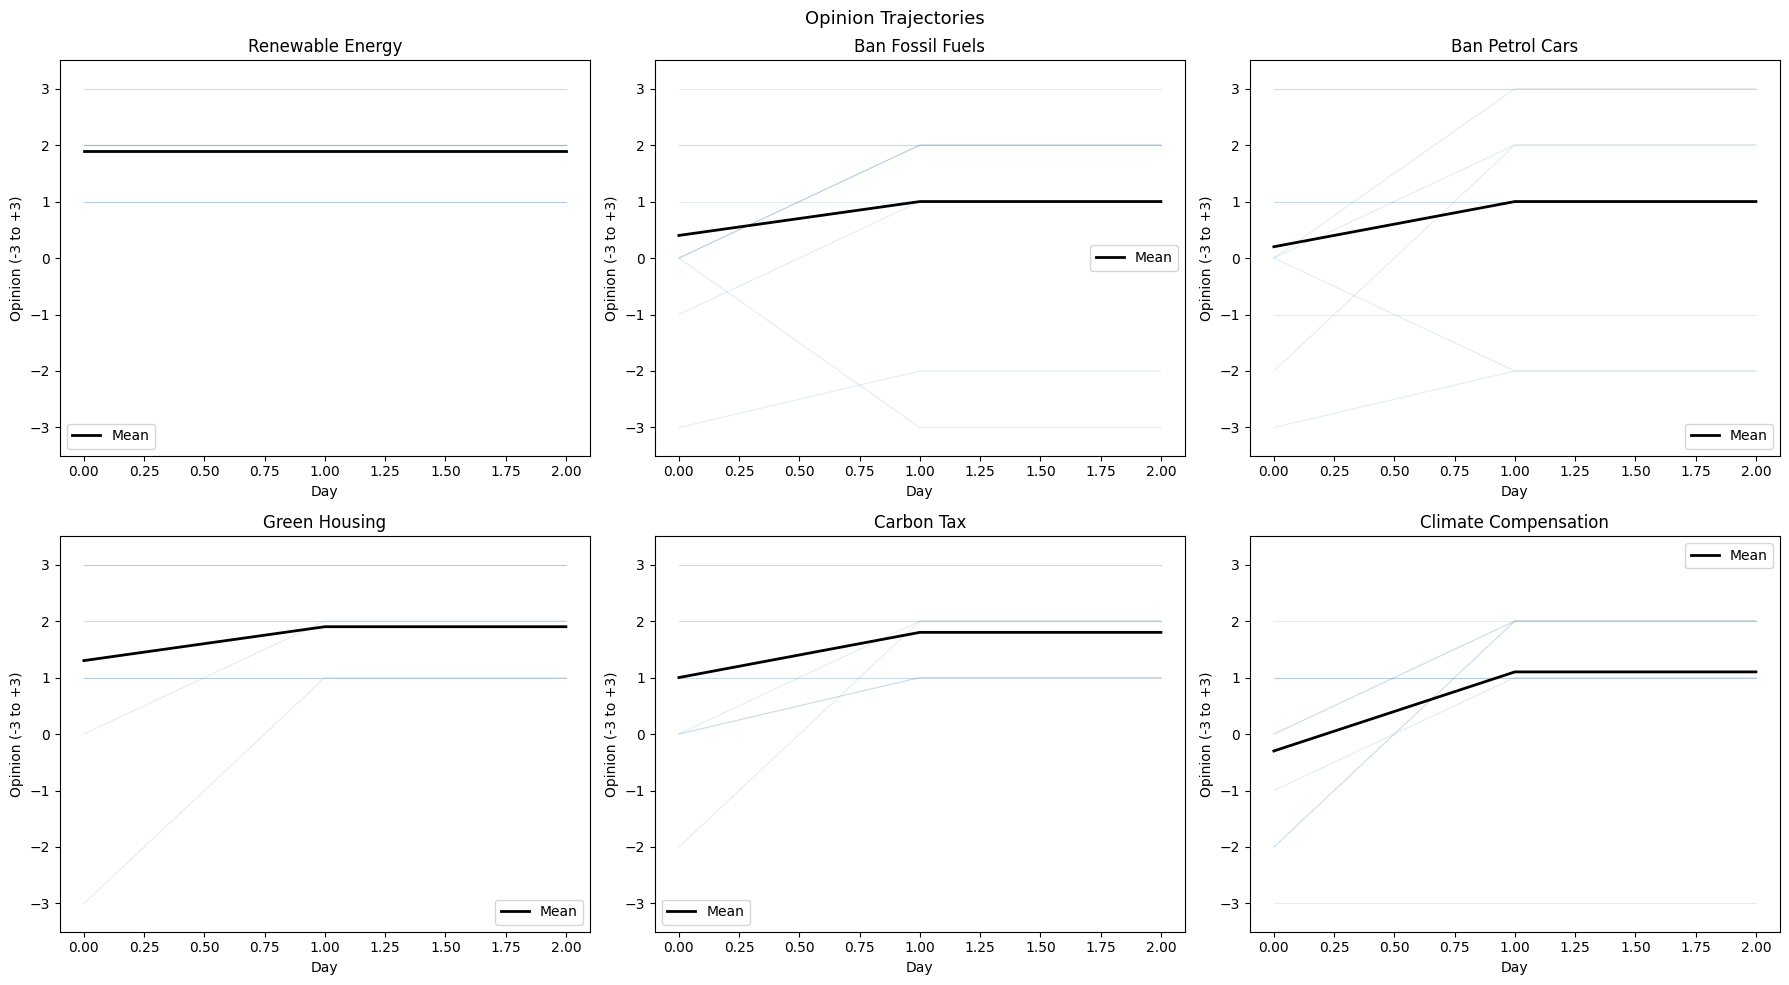

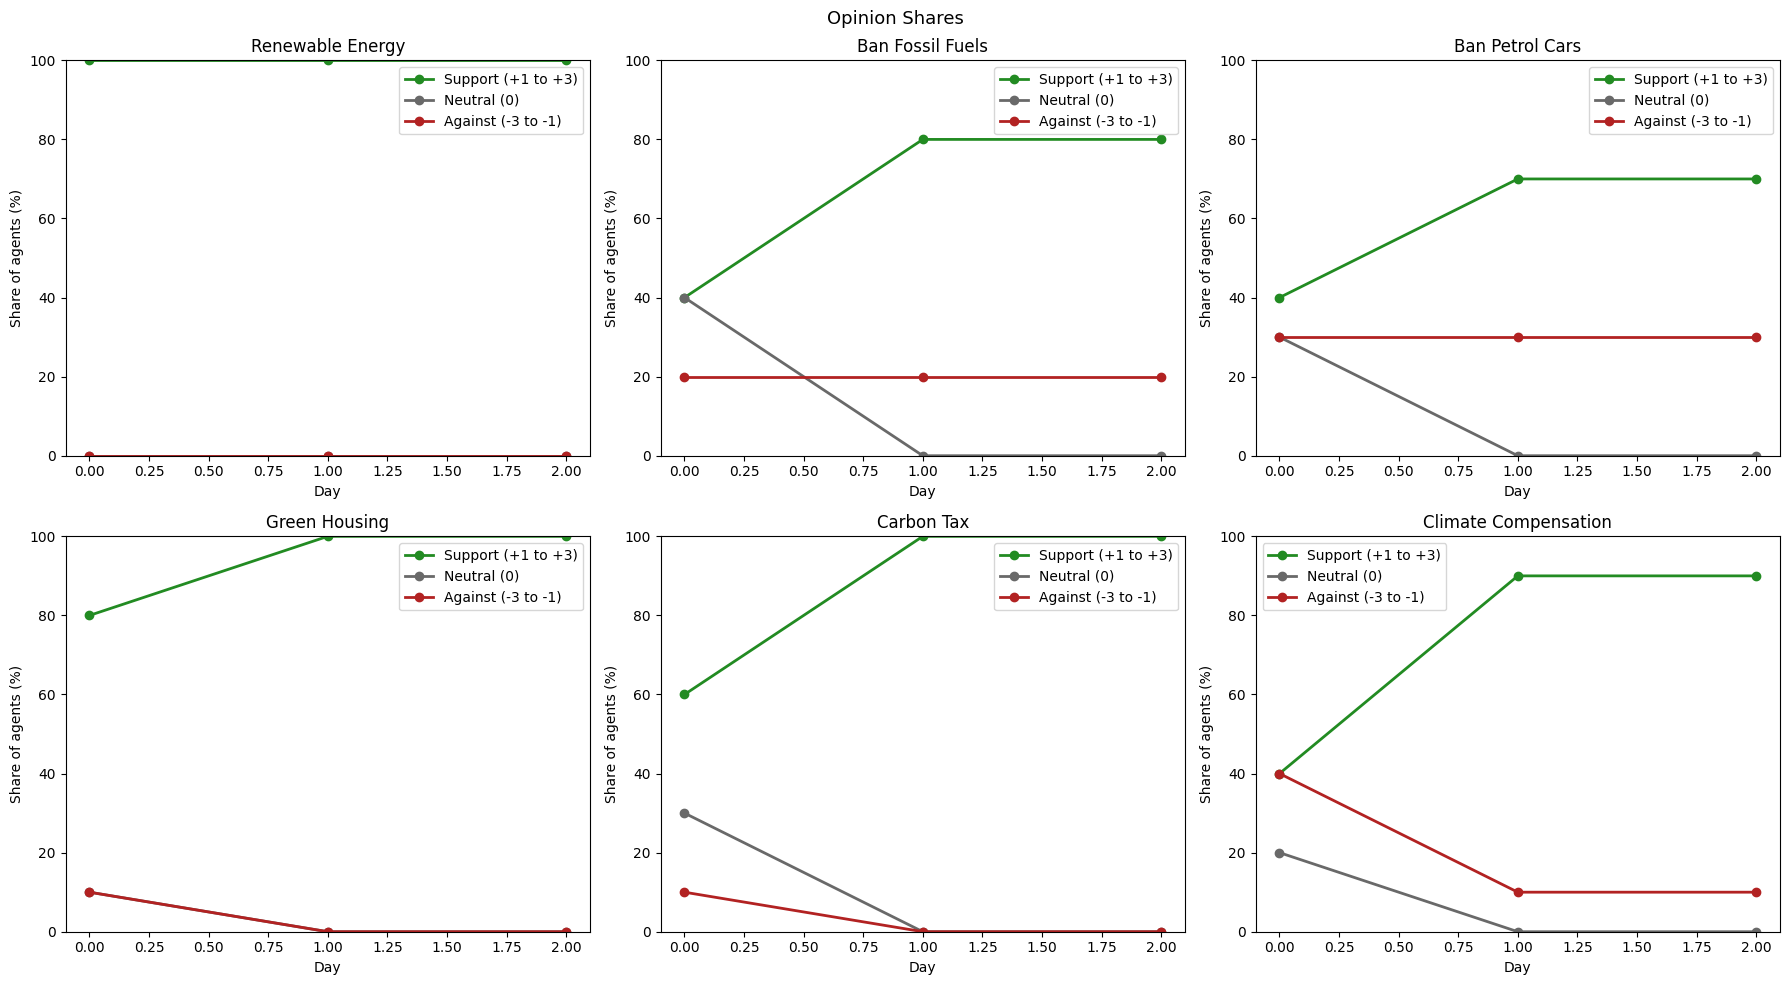

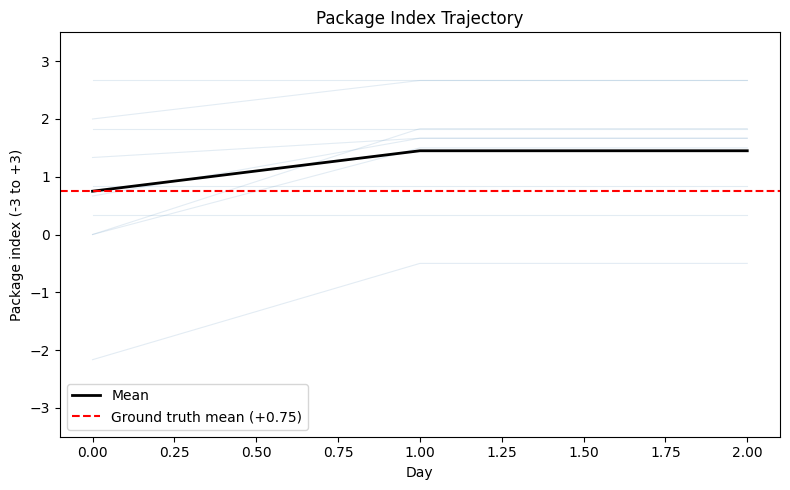

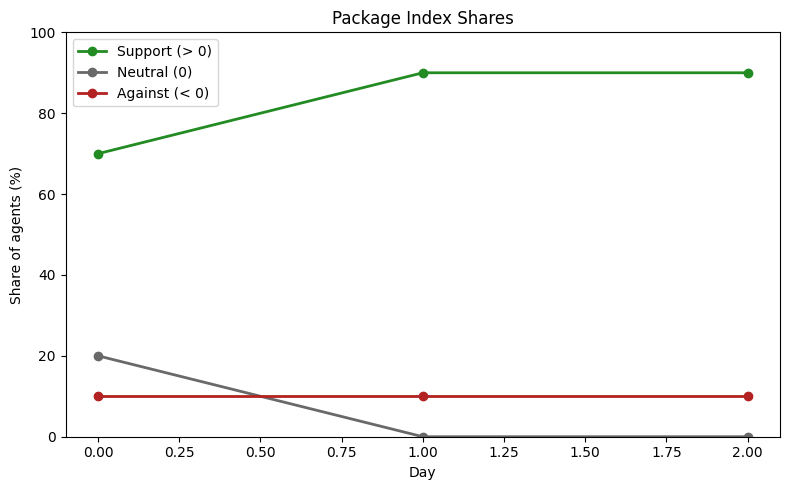

In [7]:
from cag.abm.sim import save_results, save_result_plots

out_path = save_results(results, output_dir='../data/output/experiments')
plot_paths = save_result_plots(results, out_path)

print('Artifacts written to:')
print(' ', out_path)
print('\nPlot files:')
for name, p in plot_paths.items():
    print(f'  {name:40s} -> {p}')

## 7. Validate offline broadcasts round-trip

Every `political_broadcast` row in `results['messages']` must (a) carry a non-empty `political_message_id`, (b) resolve via `pool.get_record(id)` back to a record whose `message_text` matches the row's `message_text` byte-for-byte, and (c) have a side letter (`A` / `B`) consistent with the row's `sender_side` (`pro_climate` / `anti_climate`).

In [8]:
df_messages = results['messages']
broadcasts  = df_messages[df_messages['message_type'] == 'political_broadcast'].copy()
print(f'political_broadcast rows: {len(broadcasts)}')

assert (broadcasts['political_message_id'] != '').all(), \
    'offline mode should populate political_message_id on every broadcast row'

SIDE_LETTER = {'pro_climate': 'A', 'anti_climate': 'B'}

mismatches = []
for _, row in broadcasts.iterrows():
    rec = pool.get_record(row['political_message_id'])
    if rec is None:
        mismatches.append((row['political_message_id'], 'unknown id'))
        continue
    if rec.message_text != row['message_text']:
        mismatches.append((row['political_message_id'], 'text mismatch'))
    expected_letter = SIDE_LETTER.get(row['sender_side'])
    if rec.side != expected_letter:
        mismatches.append((row['political_message_id'],
                          f'side mismatch {rec.side}!={expected_letter} (sender_side={row["sender_side"]})'))

print(f'mismatches: {len(mismatches)} (must be 0)')
if mismatches:
    print(mismatches[:5])

print('\nUnique message ids used (top 15):')
print(broadcasts['political_message_id'].value_counts().head(15))

political_broadcast rows: 16
mismatches: 0 (must be 0)

Unique message ids used (top 15):
political_message_id
A_PKG_20    4
B_PKG_05    4
B_PKG_04    4
A_PKG_10    4
Name: count, dtype: int64


## 8. Headline metrics

Three quick sanity readouts:

1. **Day-0 anchor invariant** — under `day0_anchor='ground_truth_with_rationale'`, the numeric Day-0 opinion for every (agent, policy) must equal the ground-truth Day-0 value exactly. Any difference is a regression in the anchor path.
2. **Reflection budget** — count and median token length of citizen end-of-day reflections, to sanity-check that the local model isn't producing degenerate empties.
3. **Package-index trajectory** — single inline plot of pro-climate package-index means over days (the simplest signal that the loop did something).

In [2]:
from pathlib import Path
import json
import pandas as pd

run_dir = Path('/Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/experiments/20260522_234958')
assert run_dir.exists(), f'Run directory not found: {run_dir}'

csv_keys = [
    'opinion_trajectories',
    'package_index_trajectories',
    'reflections',
    'messages',
    'survey_reasoning',
    'daily_summaries',
    'ground_truth',
    'package_ground_truth',
]

results = {}
for key in csv_keys:
    p = run_dir / f'{key}.csv'
    results[key] = pd.read_csv(p) if p.exists() else pd.DataFrame()

cfg_path = run_dir / 'config.json'
config = json.loads(cfg_path.read_text()) if cfg_path.exists() else {'days': []}
results['config'] = config

# Keep section-8 title rendering stable even in fresh kernels
N_CITIZENS = int(results['ground_truth']['agent_id'].nunique()) if not results['ground_truth'].empty else config.get('n_citizens', 0)

print('Loaded run:', run_dir)
for k in csv_keys:
    print(f'  {k:26s} -> {len(results[k])} rows')
print('  config days               ->', len(config.get('days', [])))
print('  inferred N_CITIZENS       ->', N_CITIZENS)

Loaded run: /Users/vbwt265/src/GitHub/Climate-Action-GABM/data/output/experiments/20260522_234958
  opinion_trajectories       -> 180 rows
  package_index_trajectories -> 30 rows
  reflections                -> 32 rows
  messages                   -> 36 rows
  survey_reasoning           -> 180 rows
  daily_summaries            -> 0 rows
  ground_truth               -> 60 rows
  package_ground_truth       -> 10 rows
  config days               -> 2
  inferred N_CITIZENS       -> 10


Day-0 anchor mismatches (must be 0): 0 of 60 (agent, policy) cells

Reflections: n=32, median tokens=168, min=98, max=389


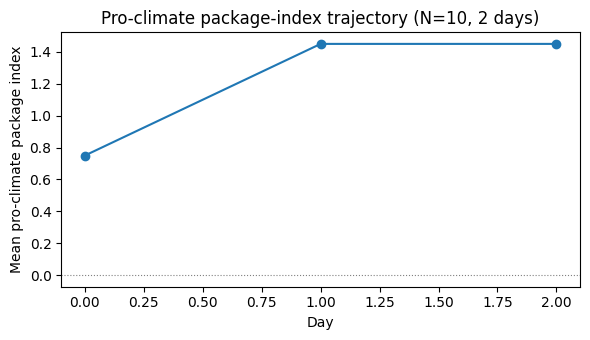

In [6]:
# 1. Day-0 anchor invariant
opin = results['opinion_trajectories']
gt   = results['ground_truth']

opin_col = 'numeric' if 'numeric' in opin.columns else 'opinion_numeric'
gt_col_candidates = ['ground_truth_numeric', 'ground_truth', 'numeric']
gt_col = next((c for c in gt_col_candidates if c in gt.columns), None)
assert gt_col is not None, f'No ground-truth numeric column found in ground_truth columns: {list(gt.columns)}'

day0_opin = opin[opin['day'] == 0][['agent_id', 'policy_id', opin_col]].rename(
    columns={opin_col: 'opinion_day0'})
gt_min    = gt[['agent_id', 'policy_id', gt_col]].rename(columns={gt_col: 'ground_truth_numeric'})
merged    = day0_opin.merge(gt_min, on=['agent_id', 'policy_id'], how='inner')
merged['diff'] = merged['opinion_day0'] - merged['ground_truth_numeric']
n_mismatch = int((merged['diff'].abs() > 1e-9).sum())
print(f'Day-0 anchor mismatches (must be 0): {n_mismatch} of {len(merged)} (agent, policy) cells')

# 2. Reflection budget
refl = results.get('reflections')
if refl is not None and len(refl) > 0:
    refl_col = 'text' if 'text' in refl.columns else 'reflection_text'
    refl_lens = refl[refl_col].astype(str).str.split().str.len()
    print(f'\nReflections: n={len(refl)}, median tokens={refl_lens.median():.0f}, '
          f'min={refl_lens.min()}, max={refl_lens.max()}')
else:
    print('\nNo reflections produced (check end-of-day step).')

# 3. Package-index trajectory plot
pkg = results.get('package_index_trajectories')
if pkg is not None and len(pkg) > 0:
    import matplotlib.pyplot as plt

    pkg_plot = pkg
    if 'index_name' in pkg_plot.columns:
        mask = pkg_plot['index_name'].astype(str).str.contains('pro_climate', case=False, na=False)
        if mask.any():
            pkg_plot = pkg_plot[mask]

    idx_col = 'pro_climate_index' if 'pro_climate_index' in pkg_plot.columns else 'package_index'
    daily_mean = pkg_plot.groupby('day')[idx_col].mean()

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(daily_mean.index, daily_mean.values, marker='o')
    ax.axhline(0, color='grey', linestyle=':', linewidth=0.8)
    ax.set_xlabel('Day')
    ax.set_ylabel('Mean pro-climate package index')
    ax.set_title(f'Pro-climate package-index trajectory (N={N_CITIZENS}, {len(config["days"])} days)')
    plt.tight_layout()
    plt.show()
else:
    print('\nNo package_index_trajectories in results (unexpected for package mode).')

## 9. Conclusion

This notebook validates the canonical full-flow profile against observed outputs.

### What passed (output-backed)

1. Local server availability (Section 1): reachable at `http://localhost:8080/v1`, model list returned `mlx-community/Qwen3-8B-4bit`.
2. Offline message-pool integrity (Section 2): `Total cells: 14`, `Empty cells: 0`.
3. Population build (Section 3): `Citizens loaded: 10 (target 10)`.
4. Config completeness and canonical settings (Section 4): all `32` `SIM_CONFIG` keys explicit; run configured as `communication_mode=package`, `political_message_source=offline (set v1)`, `llm_provider/model=local/mlx-community/Qwen3-8B-4bit`, `debias=True`, `day0_anchor=ground_truth_with_rationale`, `seed=42`.
5. Full simulation execution (Section 5): completed in `251.1 min (15067s)` with political broadcast tripwire at zero (`generate_message=0`, `generate_package_message=0`).
6. Artifact writeout (Section 6): run saved to `../data/output/experiments/20260522_234958` with all four canonical plots (`opinion_trajectories`, `opinion_shares`, `package_index_trajectories`, `package_index_shares`).
7. Offline-broadcast round-trip (Section 7): `political_broadcast rows: 16`, `mismatches: 0`; sampled IDs include `A_PKG_20`, `B_PKG_05`, `B_PKG_04`, `A_PKG_10`.
8. Headline metrics from saved run reload (Section 8): loaded rows are `opinion_trajectories=180`, `package_index_trajectories=30`, `reflections=32`, `messages=36`, `survey_reasoning=180`, `ground_truth=60`, `package_ground_truth=10`; `config days=2`, inferred `N=10`.
9. Day-0 anchor invariant and reflection budget (Section 8): `Day-0 anchor mismatches: 0 of 60`; reflections `n=32`, median tokens `168` (min `98`, max `389`).
10. Package-index trajectory signal (Section 8 plot): mean pro-climate package index rises from Day 0 to Day 1 and remains elevated through Day 2 (roughly `0.75 -> 1.45 -> 1.45`).

### Overall verdict

The canonical profile is behaving as intended on this smoke-sized cohort: offline broadcasts are correctly sourced from the pool (no LLM political-message calls), package-mode outputs are internally consistent, Day-0 anchoring is exact, and the saved artifacts are complete and replayable.

### Notes

- This notebook now includes a disk-reload cell so Section 8 can be rerun in a fresh kernel directly from `data/output/experiments/20260522_234958`.
- To scale, increase `N_CITIZENS` and extend `days`; the qualitative checks above should remain the first acceptance gate for each new run size.